In [2]:
from tqdm import tqdm
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th

import gymnasium as gym
import sys
import os

# sys.path.append(os.path.abspath(".."))
sys.path.insert(0, os.path.abspath(".."))
import importlib
if "gym_anytrading" in sys.modules:
    del sys.modules["gym_anytrading"]      # remove cached version
    del sys.modules["gym_anytrading.envs"] # remove submodule cache too

import gym_anytrading   

from stable_baselines3 import PPO,DQN
from stable_baselines3.common.callbacks import BaseCallback

In [3]:
# !pip install stable-baselines3[extra]

In [4]:
# Create Env
env_name = "stocks-v0"
env = gym.make(env_name)

In [5]:
def print_stats(reward_over_episodes):
    avg = np.mean(reward_over_episodes)
    min = np.min(reward_over_episodes)
    max = np.max(reward_over_episodes)

    print(f"Average Reward: {avg}")
    print(f"Minimum Reward: {min}")
    print(f"Maximum Reward: {max}")

    return min,avg,max

In [6]:
class ProgressBarCallback(BaseCallback):
    def __init__(self,check_freq: int,verbose: int=1):
        super().__init__(verbose)
        self.check_freq = check_freq
    
    """calling this method before the first rollout starts (i.e. before the first call to the `env.step()` method)"""
    def _on_training_start(self) -> None:
        self.progress_bar = tqdm(total = self.model._total_timesteps, desc = "model.learn()")
    
    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            self.progress_bar.update(self.check_freq)

        return True
    
    def _on_training_end(self) -> None:
        self.progress_bar.close()
    

In [7]:
# training+test
def train_test_model(model,env,seed,total_num_episodes,total_learning_timesteps=10_000):

    print("-"*80)
    # Every run starts with same initial state
    obs = env.reset(seed=seed)
    # same Weight initialization
    th.manual_seed(seed)
    # Controls python's built-in randomness 
    random.seed(seed)
    # Controls numpy randomness (Sampling)
    np.random.seed(seed)

    vec_env = None

    if model is not None:
        print(f'Model {type(model)}')
        print(f"Policy: {type(model.policy)}")
        
        model.learn(total_timesteps=total_learning_timesteps,callback=ProgressBarCallback(check_freq=100))

        vec_env = model.get_env()
        obs = vec_env.reset()
    else:
        print("Random Actions")
    
    reward_over_episodes = []

    tbar = tqdm(range(total_num_episodes))

    for episode in tbar:

        if vec_env:
            obs = vec_env.reset()
        else:
            obs, info = env.reset()
        
        total_reward = 0
        done = False

        while not done:
            if model is not None:
                action, _ = model.predict(obs)
                try:
                    obs, reward, done, info = vec_env.step(action)
                    reward = float(reward[0])
                    done = bool(done[0])
                except IndexError:
                    obs = vec_env.reset()
                    reward, done = 0.0, True
            else:
                action = env.action_space.sample()
                try:
                    obs, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                except IndexError:
                    obs, _ = env.reset()
                    reward, done = 0.0, True
            total_reward += reward
            if done:
                break

        reward_over_episodes.append(total_reward)

        if episode % 10 == 0:
            avg_reward= np.mean(reward_over_episodes)
            tbar.set_description(f'Episode: {episode}, Avg. Reward: {avg_reward:.3f}')
            tbar.update()
    
    tbar.close()
    avg_reward = np.mean(reward_over_episodes)

    return reward_over_episodes

In [8]:
seed = 42
total_num_episodes = 100

print("env_name:", env_name)
print("seed:",seed)

plot_settings = {}
plot_data = {'x': [i for i in range(1,total_num_episodes+1)]}

model = None
total_learning_timesteps = 0
rewards = train_test_model(model,env,seed,total_num_episodes, total_learning_timesteps)
min, avg, max = print_stats(rewards)

class_name = f"Random actions"
label = f"Avg. {avg:>7.2f} : {class_name}"
plot_data['rnd_rewards'] = rewards
plot_settings['rnd_rewards'] = {'label': label}

learning_timesteps_list_in_K = [25]

model_class_list = [PPO, DQN]

for timesteps in learning_timesteps_list_in_K:
    total_learning_timesteps = timesteps * 1000
    step_key = f'{timesteps}K'
    
    for model_class in model_class_list:
        policy_dict = model_class.policy_aliases
        
        policy = policy_dict.get('MlpPolicy')
        if policy is None:
            policy = policy_dict.get('MlpLstmPolicy')
        
        try:
            model = model_class(policy, env, verbose=0)
            class_name = type(model).__qualname__
            plot_key = f'{class_name}_rewards_'+step_key
            rewards = train_test_model(model, env, seed, total_num_episodes, total_learning_timesteps)
            min, avg, max, = print_stats(rewards)
            label = f'Avg. {avg:>7.2f} : {class_name} - {step_key}'
            plot_data[plot_key] = rewards
            plot_settings[plot_key] = {'label': label}    
            if 'trained_agents' not in globals():
                trained_agents = {}
            trained_agents[class_name] = model 
                   
        except Exception as e:
            print(f"ERROR: {str(e)}")
            continue



env_name: stocks-v0
seed: 42
--------------------------------------------------------------------------------
Random Actions


Episode: 90, Avg. Reward: 257.046: 100%|██████████| 100/100 [00:02<00:00, 37.69it/s]


Average Reward: 253.8946533203125
Minimum Reward: -219.9830780029297
Maximum Reward: 752.8945922851562
--------------------------------------------------------------------------------
Model <class 'stable_baselines3.ppo.ppo.PPO'>
Policy: <class 'stable_baselines3.common.policies.ActorCriticPolicy'>


model.learn(): 26600it [01:22, 322.88it/s]                           
Episode: 90, Avg. Reward: 609.445: 100%|██████████| 100/100 [03:29<00:00,  2.10s/it]


Average Reward: 608.1989044189453
Minimum Reward: -30.121124267578125
Maximum Reward: 1216.0739135742188
--------------------------------------------------------------------------------
Model <class 'stable_baselines3.dqn.dqn.DQN'>
Policy: <class 'stable_baselines3.dqn.policies.DQNPolicy'>


Episode: 90, Avg. Reward: 78.800: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s]

Average Reward: 79.5901139831543
Minimum Reward: -7.7202301025390625
Maximum Reward: 212.116455078125


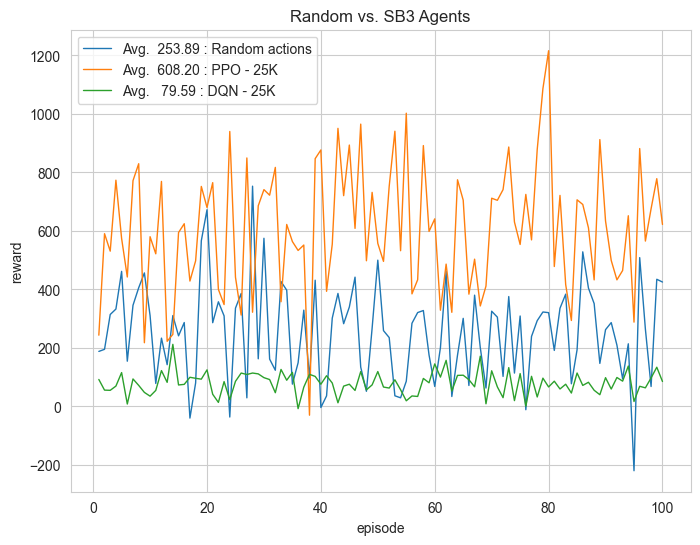

In [9]:
data = pd.DataFrame(plot_data)

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))

for key in plot_data:
    if key == 'x':
        continue
    label = plot_settings[key]['label']
    line = plt.plot('x', key, data=data, linewidth=1, label=label)

plt.xlabel('episode')
plt.ylabel('reward')
plt.title('Random vs. SB3 Agents')
plt.legend()
plt.show()

In [10]:
# !pip install plotly

In [11]:
# import plotly.graph_objects as go

# fig = go.Figure()
# colors = {'PPO': '#00ffcc', 'DQN': '#ff00ff'} # Cyberpunk Green vs Magenta

# # Loop through both agents simultaneously!
# for agent_name, agent_brain in trained_agents.items():
    
#     # 1. Spin up a fresh, perfectly fair environment for the agent
#     env_eval = gym.make(env_name)
#     obs, info = env_eval.reset(seed=42) # Seed 42 guarantees they trade on identical days
#     done = False
    
#     # 2. Let the agent trade for an entire episode
#     while not done:
#         action, _ = agent_brain.predict(obs) 
#         obs, reward, terminated, truncated, info = env_eval.step(action)
#         done = terminated or truncated
        
#     # 3. Extract the agent's exact bank balance step-by-step
#     profit_history = env_eval.unwrapped.history['total_profit']
    
#     # 4. Plot this agent's line!
#     fig.add_trace(go.Scatter(
#         y=profit_history, 
#         mode='lines', 
#         name=f'{agent_name} Total Profit',
#         line=dict(color=colors.get(agent_name, 'white'), width=2)
#     ))

# # Add a dotted red baseline representing their Starting Money (1.0)
# fig.add_trace(go.Scatter(
#     y=[1.0] * len(profit_history), 
#     mode='lines', 
#     name='Starting Balance (1.0)',
#     line=dict(color='red', width=1, dash='dash')
# ))

# fig.update_layout(
#     title='Head-to-Head Battle: PPO vs DQN Growth Curve',
#     xaxis_title='Trading Steps (Timeline)',
#     yaxis_title='Multiplier (e.g. 1.2 = 20% Profit)',
#     template='plotly_dark'
# )

# fig.show()


In [12]:
import plotly.graph_objects as go

ppo_model = trained_agents['PPO']

# frame_bound[0] must be >= window_size (30) to avoid a negative slice index
env_evaluate = gym.make(env_name, frame_bound=(50, 300))
obs, info = env_evaluate.reset(seed=42)
done = False

tick_history = []
price_history = []
action_history = []

while not done:
    action, _ = ppo_model.predict(obs)

    tick = env_evaluate.unwrapped._current_tick
    price = env_evaluate.unwrapped.prices[tick]

    obs, reward, terminated, truncated, info = env_evaluate.step(action)
    done = terminated or truncated

    tick_history.append(tick)
    price_history.append(price)
    action_history.append(int(action))


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tick_history,
    y=price_history,
    mode='lines',
    name='Stock Price',
    line=dict(color='gray')
))

buy_ticks, buy_prices = [], []
sell_ticks, sell_prices = [], []

prev_action = action_history[0]

for i in range(1, len(action_history)):
    if action_history[i] == 1 and prev_action == 0:
        buy_ticks.append(tick_history[i])
        buy_prices.append(price_history[i])
    elif action_history[i] == 0 and prev_action == 1:
        sell_ticks.append(tick_history[i])
        sell_prices.append(price_history[i])
    prev_action = action_history[i]

fig.add_trace(go.Scatter(
    x=buy_ticks,
    y=buy_prices,
    mode='markers',
    name='Buy',
    marker=dict(color='lime', size=12, symbol='triangle-up')
))

fig.add_trace(go.Scatter(
    x=sell_ticks,
    y=sell_prices,
    mode='markers',
    name='Sell',
    marker=dict(color='red', size=12, symbol='triangle-down')
))

fig.update_layout(
    title='PPO Trading Strategy — Buy/Sell Signals',
    xaxis_title='Time Step',
    yaxis_title='Price',
    xaxis=dict(rangeslider=dict(visible=True)),
    template='plotly_dark'
)

fig.show()


In [13]:
import plotly.graph_objects as go

dqn_model = trained_agents['DQN']

# frame_bound[0] must be >= window_size (30) to avoid a negative slice index
env_evaluate = gym.make(env_name, frame_bound=(50, 300))
obs, info = env_evaluate.reset(seed=42)
done = False

tick_history = []
price_history = []
action_history = []

while not done:
    action, _ = dqn_model.predict(obs)

    tick = env_evaluate.unwrapped._current_tick
    price = env_evaluate.unwrapped.prices[tick]

    obs, reward, terminated, truncated, info = env_evaluate.step(action)
    done = terminated or truncated

    tick_history.append(tick)
    price_history.append(price)
    action_history.append(int(action))


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tick_history,
    y=price_history,
    mode='lines',
    name='Stock Price',
    line=dict(color='gray')
))

buy_ticks, buy_prices = [], []
sell_ticks, sell_prices = [], []

prev_action = action_history[0]

for i in range(1, len(action_history)):
    if action_history[i] == 1 and prev_action == 0:
        buy_ticks.append(tick_history[i])
        buy_prices.append(price_history[i])
    elif action_history[i] == 0 and prev_action == 1:
        sell_ticks.append(tick_history[i])
        sell_prices.append(price_history[i])
    prev_action = action_history[i]

fig.add_trace(go.Scatter(
    x=buy_ticks,
    y=buy_prices,
    mode='markers',
    name='Buy',
    marker=dict(color='lime', size=12, symbol='triangle-up')
))

fig.add_trace(go.Scatter(
    x=sell_ticks,
    y=sell_prices,
    mode='markers',
    name='Sell',
    marker=dict(color='red', size=12, symbol='triangle-down')
))

fig.update_layout(
    title='DQN Trading Strategy — Buy/Sell Signals',
    xaxis_title='Time Step',
    yaxis_title='Price',
    xaxis=dict(rangeslider=dict(visible=True)),
    template='plotly_dark'
)

fig.show()


In [14]:
# # Convert our dictionary to a format Seaborn loves
# df_melted = data.drop(columns=['x']).melt(var_name='Agent', value_name='Total Reward')

# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Agent', y='Total Reward', data=df_melted, palette="Set2")
# plt.title("Agent Reward Distribution & Risk Assessment")
# plt.ylabel("Total Profit per Episode")
# plt.show()


In [15]:
# # env_evaluate.history stores the step-by-step financial metrics
# profit_history = env_evaluate.unwrapped.history['total_profit']

# plt.figure(figsize=(12, 5))
# plt.plot(profit_history, label='AI Portfolio Valuation', color='green')
# plt.axhline(1.0, color='red', linestyle='--', label='Initial Baseline') # Starting Money
# plt.title("Portfolio Equity Curve over Time")
# plt.ylabel("Multiplier / Net Worth")
# plt.xlabel("Trading Steps / Days")
# plt.legend()
# plt.show()


In [16]:
trained_agents['PPO'].save("trained_PPO_stock_agent")
trained_agents['DQN'].save("trained_DQN_stock_agent")

print("Models saved:")
print("  PPO -> trained_PPO_stock_agent.zip")
print("  DQN -> trained_DQN_stock_agent.zip")

Models saved:
  PPO -> trained_PPO_stock_agent.zip
  DQN -> trained_DQN_stock_agent.zip
